In [48]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [49]:
data = pd.read_csv('data/train.csv')
data = data.fillna(0)

# Encode the data
from sklearn.preprocessing import LabelEncoder

df_encoded = data.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Normalise the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.drop(['id', 'diagnosis'])
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [50]:
# Create early stopping callback
class EarlyStopping:
    def __init__(self, patience, min_delta, restore_best_weights):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_loss = None
        self.best_model_state = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.restore_best_weights:
                self.best_model_state = model.state_dict()
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_state = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_model_state is not None:
                    model.load_state_dict(self.best_model_state)

In [51]:
# Split the data into features and target
X = torch.tensor(df_encoded.drop(['id', 'diagnosis'], axis=1).values, dtype=torch.float32)
y = torch.tensor(df_encoded['diagnosis'].values, dtype=torch.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


model = nn.Sequential(
    nn.Linear(X.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

Epoch 1, Train Loss: 0.6776, Val Loss: 0.6426
Epoch 2, Train Loss: 0.6116, Val Loss: 0.5639
Epoch 3, Train Loss: 0.5176, Val Loss: 0.4577
Epoch 4, Train Loss: 0.4164, Val Loss: 0.3408
Epoch 5, Train Loss: 0.3226, Val Loss: 0.2419
Epoch 6, Train Loss: 0.2428, Val Loss: 0.1742
Epoch 7, Train Loss: 0.2053, Val Loss: 0.1309
Epoch 8, Train Loss: 0.1551, Val Loss: 0.1044
Epoch 9, Train Loss: 0.1318, Val Loss: 0.0881
Epoch 10, Train Loss: 0.1198, Val Loss: 0.0775
Epoch 11, Train Loss: 0.1057, Val Loss: 0.0702
Epoch 12, Train Loss: 0.0983, Val Loss: 0.0663
Epoch 13, Train Loss: 0.0922, Val Loss: 0.0628
Epoch 14, Train Loss: 0.0810, Val Loss: 0.0599
Epoch 15, Train Loss: 0.0875, Val Loss: 0.0583
Epoch 16, Train Loss: 0.0767, Val Loss: 0.0569
Epoch 17, Train Loss: 0.0683, Val Loss: 0.0557
Epoch 18, Train Loss: 0.0867, Val Loss: 0.0548
Epoch 19, Train Loss: 0.0757, Val Loss: 0.0558
Epoch 20, Train Loss: 0.0673, Val Loss: 0.0560
Epoch 21, Train Loss: 0.0633, Val Loss: 0.0555
Epoch 22, Train Loss: 

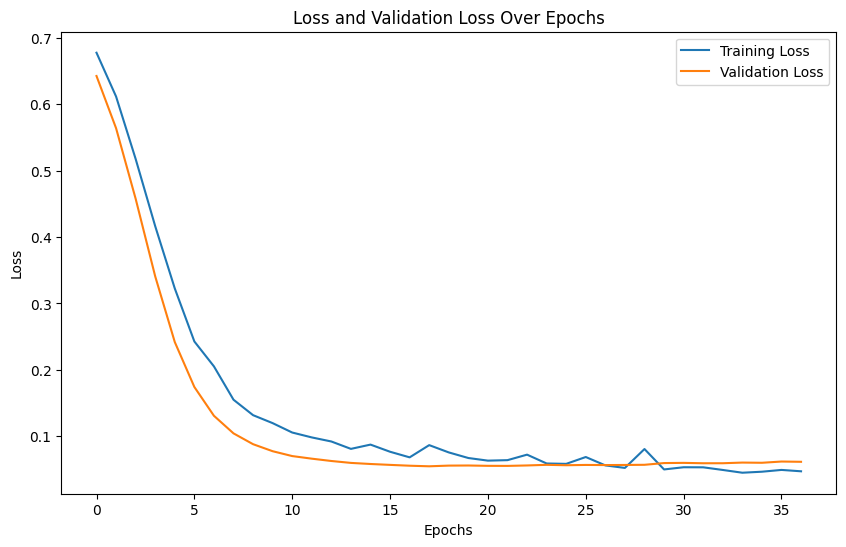

In [52]:
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()
num_epochs = 100
train_losses = []
val_losses = []

early_stop = EarlyStopping(patience=20, min_delta=0.001, restore_best_weights=True)

for epoch in range(num_epochs):
    # Training...
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        y_batch = y_batch.view(-1, 1) 
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test.view(-1, 1))
        val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    # Early stopping check
    early_stop(val_loss.item(), model)
    if early_stop.early_stop:
        print("Early stopping triggered.")
        break

# Plotting the losses
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
